In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r'C:\Users\apurv\Documents\DataAnalystProjects\data\Sample - Superstore.csv', encoding='latin1')


df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month_Num'] = df['Order Date'].dt.month
df['Month'] = df['Order Date'].dt.month_name()


sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Ready to visualize!")
print("Data shape:", df.shape)

Ready to visualize!
Data shape: (9994, 24)


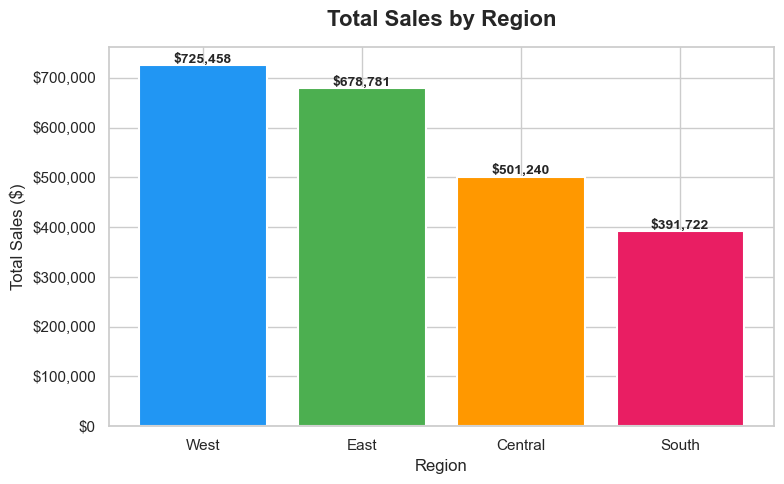

Chart saved!


In [4]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    region_sales['Region'],
    region_sales['Sales'],
    color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'],
    edgecolor='white',
    linewidth=1.5
)


for bar, val in zip(bars, region_sales['Sales']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'${val:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


ax.set_title('Total Sales by Region', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart1_region_sales.png', dpi=150)
plt.show()
print("Chart saved!")

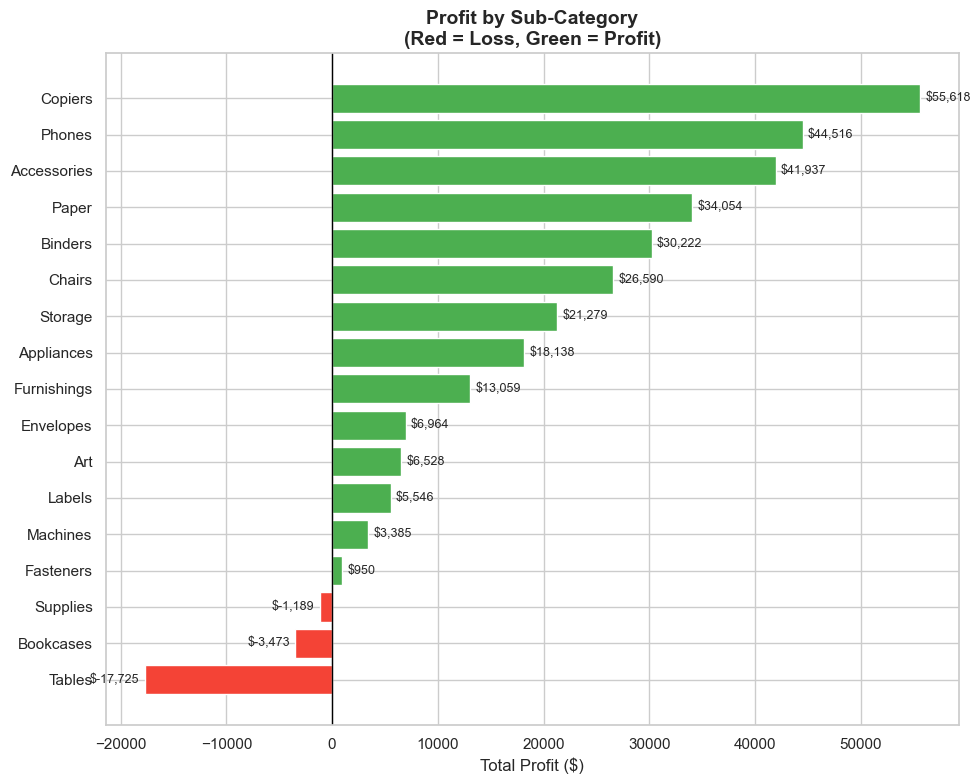

In [5]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()


colors = ['#F44336' if x < 0 else '#4CAF50' for x in sub_profit.values]

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(sub_profit.index, sub_profit.values, color=colors, edgecolor='white')


for bar, val in zip(bars, sub_profit.values):
    ax.text(
        val + (500 if val >= 0 else -500),
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )


ax.axvline(x=0, color='black', linewidth=1)

ax.set_title('Profit by Sub-Category\n(Red = Loss, Green = Profit)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart2_subcategory_profit.png', dpi=150)
plt.show()

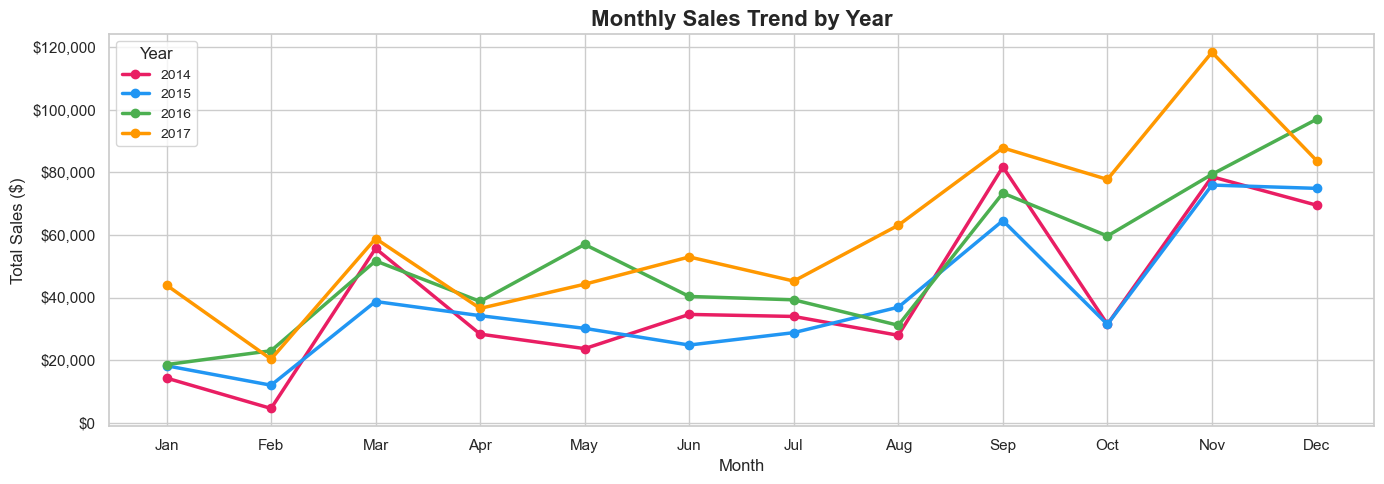

In [6]:
monthly = df.groupby(['Year', 'Month_Num', 'Month'])['Sales'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month_Num'])

fig, ax = plt.subplots(figsize=(14, 5))


colors = {2014: '#E91E63', 2015: '#2196F3', 2016: '#4CAF50', 2017: '#FF9800'}

for year in monthly['Year'].unique():
    year_data = monthly[monthly['Year'] == year]
    ax.plot(
        year_data['Month_Num'],
        year_data['Sales'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=str(year),
        color=colors.get(year, 'gray')
    )

ax.set_title('Monthly Sales Trend by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Year', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart3_monthly_trend.png', dpi=150)
plt.show()

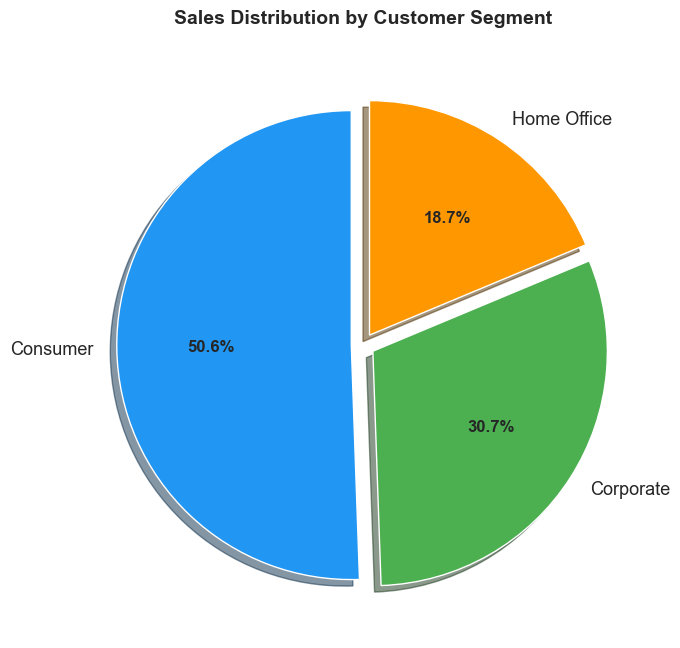

In [7]:
segment_sales = df.groupby('Segment')['Sales'].sum()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    segment_sales.values,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#4CAF50', '#FF9800'],
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True
)

for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Sales Distribution by Customer Segment',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart4_segment_pie.png', dpi=150)
plt.show()

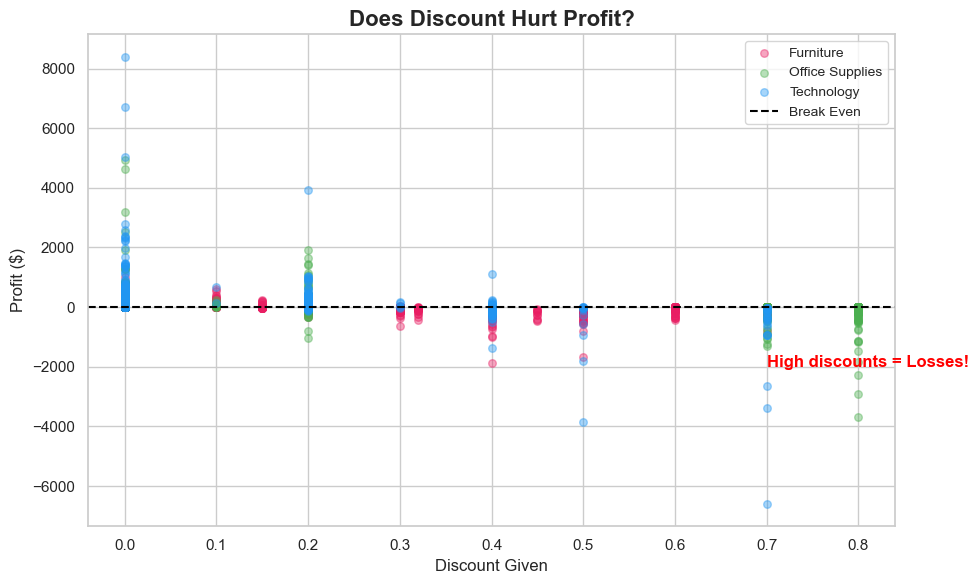

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = df['Category'].unique()
colors = {'Furniture': '#E91E63', 'Technology': '#2196F3', 'Office Supplies': '#4CAF50'}

for cat in categories:
    cat_data = df[df['Category'] == cat]
    ax.scatter(
        cat_data['Discount'],
        cat_data['Profit'],
        alpha=0.4,
        s=30,
        color=colors[cat],
        label=cat
    )

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--', label='Break Even')

ax.set_title('Does Discount Hurt Profit?', fontsize=16, fontweight='bold')
ax.set_xlabel('Discount Given', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.legend(fontsize=10)

ax.annotate('High discounts = Losses!',
            xy=(0.7, -2000),
            fontsize=12,
            color='red',
            fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart5_discount_profit.png', dpi=150)
plt.show()

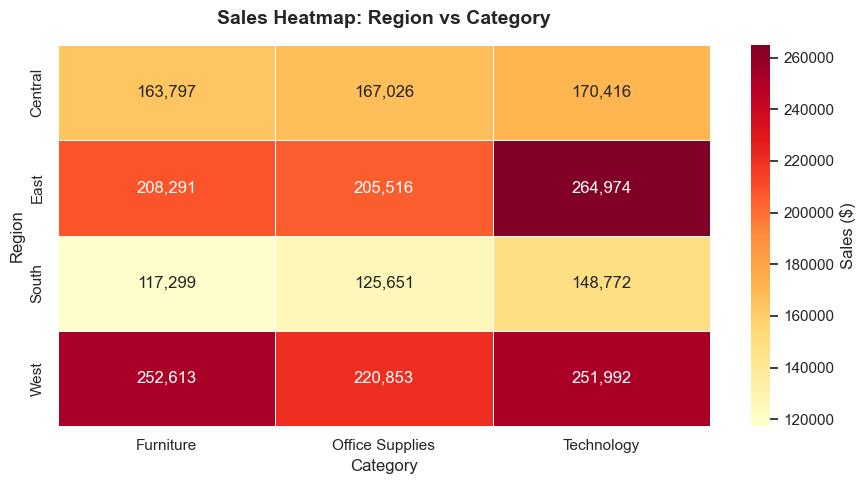

In [9]:
pivot = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
).round(0)

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Sales ($)'}
)

ax.set_title('Sales Heatmap: Region vs Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart6_heatmap.png', dpi=150)
plt.show()

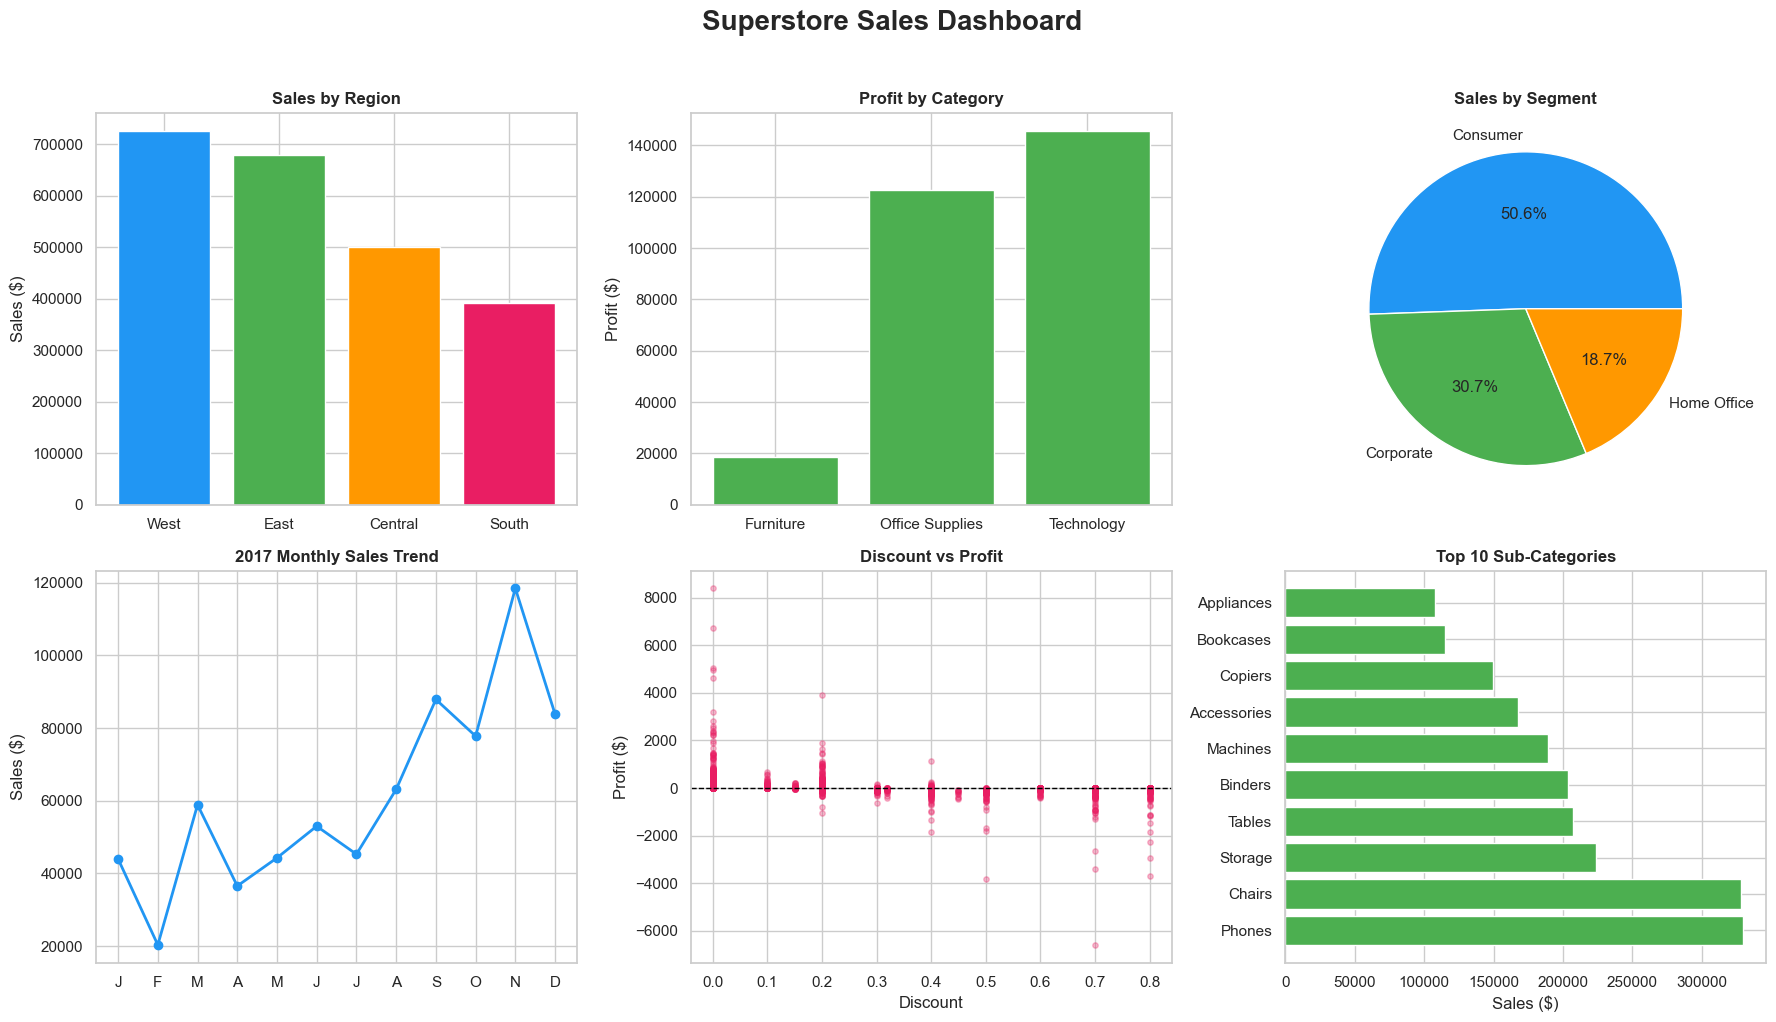

Full dashboard saved!


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Superstore Sales Dashboard', fontsize=20, fontweight='bold', y=1.02)

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values,
              color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[0,0].set_title('Sales by Region', fontweight='bold')
axes[0,0].set_ylabel('Sales ($)')

cat_profit = df.groupby('Category')['Profit'].sum()
colors_cat = ['#4CAF50' if x > 0 else '#F44336' for x in cat_profit.values]
axes[0,1].bar(cat_profit.index, cat_profit.values, color=colors_cat)
axes[0,1].set_title('Profit by Category', fontweight='bold')
axes[0,1].set_ylabel('Profit ($)')

segment_sales = df.groupby('Segment')['Sales'].sum()
axes[0,2].pie(segment_sales.values, labels=segment_sales.index,
              autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800'])
axes[0,2].set_title('Sales by Segment', fontweight='bold')

monthly_2017 = df[df['Year']==2017].groupby('Month_Num')['Sales'].sum()
axes[1,0].plot(monthly_2017.index, monthly_2017.values,
               marker='o', color='#2196F3', linewidth=2)
axes[1,0].set_title('2017 Monthly Sales Trend', fontweight='bold')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

axes[1,1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#E91E63', s=15)
axes[1,1].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[1,1].set_title('Discount vs Profit', fontweight='bold')
axes[1,1].set_xlabel('Discount')
axes[1,1].set_ylabel('Profit ($)')

top_sub = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)
axes[1,2].barh(top_sub.index, top_sub.values, color='#4CAF50')
axes[1,2].set_title('Top 10 Sub-Categories', fontweight='bold')
axes[1,2].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\apurv\Documents\DataAnalystProjects\outputs\chart7_full_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Full dashboard saved!")